# Teste de McNemar para comparações pareadas

Este notebook avalia todos os modelos sobre as mesmas imagens da partição de teste, preservando a ordem dos arquivos e dos rótulos. O teste exato de McNemar usa somente os pares discordantes. Para controlar o erro decorrente das comparações múltiplas, os valores de p também são corrigidos pelo método de Holm.

As comparações FP32 são feitas entre os modelos TFLite exportados. Portanto, os resultados medem as pipelines de implantação em FP32, não diretamente os checkpoints PyTorch. O teste avalia diferenças pareadas neste conjunto de teste fixo e não substitui experimentos com múltiplas sementes para medir a variabilidade do treinamento.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from ai_edge_litert.interpreter import Interpreter, OpResolverType
from IPython.display import display
from scipy.stats import binomtest, norm
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="paper")

## Configuração

Todos os resultados e gráficos são gravados dentro da pasta deste notebook.

In [2]:
NOTEBOOK_DIR = Path.cwd()
DATASET_DIR = Path("/home/jovyan/work/UFSC/butterflies_austria/Dataset_train_test_split/butterflies-austria")
TEST_DIR = DATASET_DIR / "test"
RESULTS_DIR = NOTEBOOK_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 64
NUM_WORKERS = 4
BOOTSTRAP_SAMPLES = 10000
RANDOM_SEED = 42
ALPHA = 0.05
RESOLVER_TYPE = OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES



In [4]:
!pwd
print(f"notebook dir: \n{NOTEBOOK_DIR}")

/home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/mcnemar_teste
notebook dir: 
/home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/mcnemar_teste


In [5]:
MODEL_SPECS = {
    "MobileNetV2 FP32": {
        "path": NOTEBOOK_DIR / "butterflies_austria_MobileNetv2_v1_esp_verify/tflite_models/model_fp32.tflite",
        "pipeline": "mobilenet",
    },
    "MobileViT-XXS FP32": {
        "path": NOTEBOOK_DIR / "butterflies_austria_MobileVIT_apple_baseline_v2_esp_verify/test1_results/mobilevit_original_fp32.tflite",
        "pipeline": "mobilevit",
    },
    "MobileViT-XXS original INT8": {
        "path": NOTEBOOK_DIR / "butterflies_austria_MobileVIT_apple_baseline_v2_esp_verify/test1_results/mobilevit_original_stratified_int8.tflite",
        "pipeline": "mobilevit",
    },
    "MobileViT-XXS g8_4_4 INT8": {
        "path": NOTEBOOK_DIR / "g8_4_4/mobilevit_g8_4_4_int8.tflite",
        "pipeline": "mobilevit",
    },
    "MobileViT-XXS g8_4_4 + b3_g4 INT8": {
        "path": NOTEBOOK_DIR / "g8_4_4_b3_g4/mobilevit_g8_4_4_b3_g4_int8.tflite",
        "pipeline": "mobilevit",
    },
}

if not TEST_DIR.is_dir():
    raise FileNotFoundError(TEST_DIR)

missing_models = [str(spec["path"]) for spec in MODEL_SPECS.values() if not spec["path"].is_file()]
if missing_models:
    raise FileNotFoundError(f"Missing models: {missing_models}")

print(f"Test directory: {TEST_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Test directory: /home/jovyan/work/UFSC/butterflies_austria/Dataset_train_test_split/butterflies-austria/test
Results directory: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/mcnemar_teste/results


## Dados e pré-processamento

A MobileNetV2 recebe imagens RGB de 224 × 224 normalizadas com as estatísticas da ImageNet. A MobileViT-XXS recebe recorte central de 256 × 256, valores no intervalo [0, 1] e canais em ordem BGR, conforme o checkpoint utilizado. Os dois datasets apontam para os mesmos arquivos; apenas a transformação de entrada difere.

In [6]:
mobilenet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

mobilevit_transform = transforms.Compose([
    transforms.Resize(288),
    transforms.CenterCrop(256),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.ToTensor(),
    transforms.Lambda(lambda image: image[[2, 1, 0]]),
])

test_datasets = {
    "mobilenet": datasets.ImageFolder(TEST_DIR, transform=mobilenet_transform),
    "mobilevit": datasets.ImageFolder(TEST_DIR, transform=mobilevit_transform),
}

reference_dataset = test_datasets["mobilenet"]
reference_samples = [
    (Path(path).relative_to(TEST_DIR).as_posix(), int(target))
    for path, target in reference_dataset.samples
]

for pipeline_name, dataset in test_datasets.items():
    samples = [
        (Path(path).relative_to(TEST_DIR).as_posix(), int(target))
        for path, target in dataset.samples
    ]
    if dataset.class_to_idx != reference_dataset.class_to_idx:
        raise RuntimeError(f"Class mapping mismatch: {pipeline_name}")
    if samples != reference_samples:
        raise RuntimeError(f"Sample order mismatch: {pipeline_name}")

test_loaders = {
    name: DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        persistent_workers=NUM_WORKERS > 0,
    )
    for name, dataset in test_datasets.items()
}

class_names = reference_dataset.classes
sample_ids = np.asarray([sample_id for sample_id, _ in reference_samples])
reference_targets = np.asarray([target for _, target in reference_samples], dtype=np.int64)

print(f"Test samples: {len(reference_targets)}")
print(f"Classes: {len(class_names)}")

Test samples: 648
Classes: 20


## Inferência TFLite pareada

Cada modelo é executado uma única vez. As predições individuais são salvas para permitir auditoria e reprodução dos testes sem depender apenas das acurácias agregadas.

In [7]:
def create_interpreter(model_path):
    interpreter = Interpreter(
        model_path=str(model_path),
        experimental_op_resolver_type=RESOLVER_TYPE,
    )
    interpreter.allocate_tensors()
    return interpreter


def prepare_input(values, input_detail):
    input_dtype = input_detail["dtype"]
    if not np.issubdtype(input_dtype, np.integer):
        return values.astype(input_dtype)

    scale, zero_point = input_detail["quantization"]
    if scale <= 0:
        raise ValueError("Invalid input quantization scale")

    limits = np.iinfo(input_dtype)
    quantized = np.round(values / scale + zero_point)
    return np.clip(quantized, limits.min, limits.max).astype(input_dtype)


def evaluate_tflite(model_path, data_loader):
    interpreter = create_interpreter(model_path)
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    targets = []
    predictions = []

    for images, labels in tqdm(data_loader, desc=model_path.stem, leave=False):
        image_values = images.numpy()
        label_values = labels.numpy()

        for image, label in zip(image_values, label_values):
            values = prepare_input(np.expand_dims(image, axis=0), input_detail)
            interpreter.set_tensor(input_detail["index"], values)
            interpreter.invoke()
            output = interpreter.get_tensor(output_detail["index"])
            predictions.append(int(np.argmax(output, axis=1)[0]))
            targets.append(int(label))

    return np.asarray(targets, dtype=np.int64), np.asarray(predictions, dtype=np.int64)

In [8]:
predictions = {}
model_accuracy_rows = []

for model_name, spec in MODEL_SPECS.items():
    targets, model_predictions = evaluate_tflite(
        spec["path"],
        test_loaders[spec["pipeline"]],
    )
    if not np.array_equal(targets, reference_targets):
        raise RuntimeError(f"Target mismatch: {model_name}")
    predictions[model_name] = model_predictions
    model_accuracy_rows.append({
        "model": model_name,
        "correct": int(np.sum(model_predictions == reference_targets)),
        "samples": len(reference_targets),
        "accuracy": float(accuracy_score(reference_targets, model_predictions)),
    })

prediction_table = pd.DataFrame({
    "sample_id": sample_ids,
    "target": reference_targets,
    "target_name": [class_names[target] for target in reference_targets],
    **predictions,
})
prediction_table.to_csv(TABLES_DIR / "paired_test_predictions.csv", index=False)

model_accuracy = pd.DataFrame(model_accuracy_rows)
model_accuracy.to_csv(TABLES_DIR / "model_accuracy.csv", index=False)
display(model_accuracy.style.format({"accuracy": "{:.4%}"}))

model_fp32:   0%|          | 0/11 [00:00<?, ?it/s]

mobilevit_original_fp32:   0%|          | 0/11 [00:00<?, ?it/s]

mobilevit_original_stratified_int8:   0%|          | 0/11 [00:00<?, ?it/s]

mobilevit_g8_4_4_int8:   0%|          | 0/11 [00:00<?, ?it/s]

mobilevit_g8_4_4_b3_g4_int8:   0%|          | 0/11 [00:00<?, ?it/s]

,model,correct,samples,accuracy
0,MobileNetV2 FP32,629,648,97.0679%
1,MobileViT-XXS FP32,631,648,97.3765%
2,MobileViT-XXS original INT8,69,648,10.6481%
3,MobileViT-XXS g8_4_4 INT8,588,648,90.7407%
4,MobileViT-XXS g8_4_4 + b3_g4 INT8,624,648,96.2963%


## Teste exato de McNemar

Para cada comparação, `model_a_correct_model_b_wrong` representa imagens acertadas apenas pelo modelo A, enquanto `model_a_wrong_model_b_correct` representa imagens acertadas apenas pelo modelo B. Sob a hipótese nula, os dois tipos de discordância têm a mesma probabilidade. O valor de p é calculado pelo teste binomial exato bilateral.

A diferença de acurácia é definida como acurácia de B menos acurácia de A. Seu intervalo de confiança de 95% é obtido por bootstrap pareado das imagens de teste.

In [9]:
def paired_bootstrap_interval(correct_a, correct_b, samples, seed):
    differences = correct_b.astype(np.int8) - correct_a.astype(np.int8)
    generator = np.random.default_rng(seed)
    estimates = np.empty(samples, dtype=np.float64)

    for index in range(samples):
        sample_indices = generator.integers(0, len(differences), len(differences))
        estimates[index] = differences[sample_indices].mean()

    lower, upper = np.quantile(estimates, [0.025, 0.975])
    return float(lower), float(upper)


def exact_mcnemar(model_a, model_b, seed):
    correct_a = predictions[model_a] == reference_targets
    correct_b = predictions[model_b] == reference_targets
    both_correct = int(np.sum(correct_a & correct_b))
    a_only = int(np.sum(correct_a & ~correct_b))
    b_only = int(np.sum(~correct_a & correct_b))
    both_wrong = int(np.sum(~correct_a & ~correct_b))
    discordant = a_only + b_only
    p_value = 1.0 if discordant == 0 else float(
        binomtest(a_only, discordant, p=0.5, alternative="two-sided").pvalue
    )
    difference = float(correct_b.mean() - correct_a.mean())
    lower, upper = paired_bootstrap_interval(
        correct_a,
        correct_b,
        BOOTSTRAP_SAMPLES,
        seed,
    )
    matched_odds_ratio = (b_only / a_only) if a_only > 0 else (np.inf if b_only > 0 else 1.0)

    return {
        "model_a": model_a,
        "model_b": model_b,
        "both_correct": both_correct,
        "model_a_correct_model_b_wrong": a_only,
        "model_a_wrong_model_b_correct": b_only,
        "both_wrong": both_wrong,
        "discordant_pairs": discordant,
        "accuracy_a": float(correct_a.mean()),
        "accuracy_b": float(correct_b.mean()),
        "accuracy_difference_b_minus_a": difference,
        "difference_ci95_lower": lower,
        "difference_ci95_upper": upper,
        "matched_odds_ratio_b_over_a": matched_odds_ratio,
        "mcnemar_exact_p_value": p_value,
    }


def holm_adjust(p_values):
    values = np.asarray(p_values, dtype=np.float64)
    order = np.argsort(values)
    adjusted_sorted = np.maximum.accumulate(
        (len(values) - np.arange(len(values))) * values[order]
    )
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = np.minimum(adjusted_sorted, 1.0)
    return adjusted

In [10]:
COMPARISONS = [
    ("MobileNetV2 FP32", "MobileViT-XXS FP32"),
    ("MobileViT-XXS FP32", "MobileViT-XXS original INT8"),
    ("MobileViT-XXS FP32", "MobileViT-XXS g8_4_4 INT8"),
    ("MobileViT-XXS FP32", "MobileViT-XXS g8_4_4 + b3_g4 INT8"),
    ("MobileViT-XXS original INT8", "MobileViT-XXS g8_4_4 INT8"),
    ("MobileViT-XXS original INT8", "MobileViT-XXS g8_4_4 + b3_g4 INT8"),
    ("MobileViT-XXS g8_4_4 INT8", "MobileViT-XXS g8_4_4 + b3_g4 INT8"),
]

mcnemar_results = pd.DataFrame([
    exact_mcnemar(model_a, model_b, RANDOM_SEED + index)
    for index, (model_a, model_b) in enumerate(COMPARISONS)
])
mcnemar_results["holm_adjusted_p_value"] = holm_adjust(
    mcnemar_results["mcnemar_exact_p_value"].to_numpy()
)
mcnemar_results["significant_after_holm"] = (
    mcnemar_results["holm_adjusted_p_value"] < ALPHA
)
mcnemar_results.insert(
    0,
    "comparison",
    mcnemar_results["model_a"] + " vs. " + mcnemar_results["model_b"],
)
mcnemar_results.to_csv(TABLES_DIR / "mcnemar_results.csv", index=False)

display_columns = [
    "comparison",
    "model_a_correct_model_b_wrong",
    "model_a_wrong_model_b_correct",
    "accuracy_difference_b_minus_a",
    "difference_ci95_lower",
    "difference_ci95_upper",
    "mcnemar_exact_p_value",
    "holm_adjusted_p_value",
    "significant_after_holm",
]
display(
    mcnemar_results[display_columns].style.format({
        "accuracy_difference_b_minus_a": "{:+.2%}",
        "difference_ci95_lower": "{:+.2%}",
        "difference_ci95_upper": "{:+.2%}",
        "mcnemar_exact_p_value": "{:.6g}",
        "holm_adjusted_p_value": "{:.6g}",
    })
)

,comparison,model_a_correct_model_b_wrong,model_a_wrong_model_b_correct,accuracy_difference_b_minus_a,difference_ci95_lower,difference_ci95_upper,mcnemar_exact_p_value,holm_adjusted_p_value,significant_after_holm
0,MobileNetV2 FP32 vs. MobileViT-XXS FP32,7,9,+0.31%,-0.93%,+1.54%,0.803619,0.803619,False
1,MobileViT-XXS FP32 vs. MobileViT-XXS original INT8,562,0,-86.73%,-89.20%,-84.10%,1.32487e-169,9.27407e-169,True
2,MobileViT-XXS FP32 vs. MobileViT-XXS g8_4_4 INT8,49,6,-6.64%,-8.80%,-4.48%,1.82283e-09,7.29134e-09,True
3,MobileViT-XXS FP32 vs. MobileViT-XXS g8_4_4 + b3_g4 INT8,9,2,-1.08%,-2.16%,-0.15%,0.0654297,0.130859,False
4,MobileViT-XXS original INT8 vs. MobileViT-XXS g8_4_4 INT8,1,520,+80.09%,+77.01%,+83.18%,1.5208e-154,7.60401e-154,True
5,MobileViT-XXS original INT8 vs. MobileViT-XXS g8_4_4 + b3_g4 INT8,0,555,+85.65%,+82.87%,+88.27%,1.69583e-167,1.0175e-166,True
6,MobileViT-XXS g8_4_4 INT8 vs. MobileViT-XXS g8_4_4 + b3_g4 INT8,6,42,+5.56%,+3.55%,+7.56%,1.00875e-07,3.02624e-07,True


## Figuras para o artigo

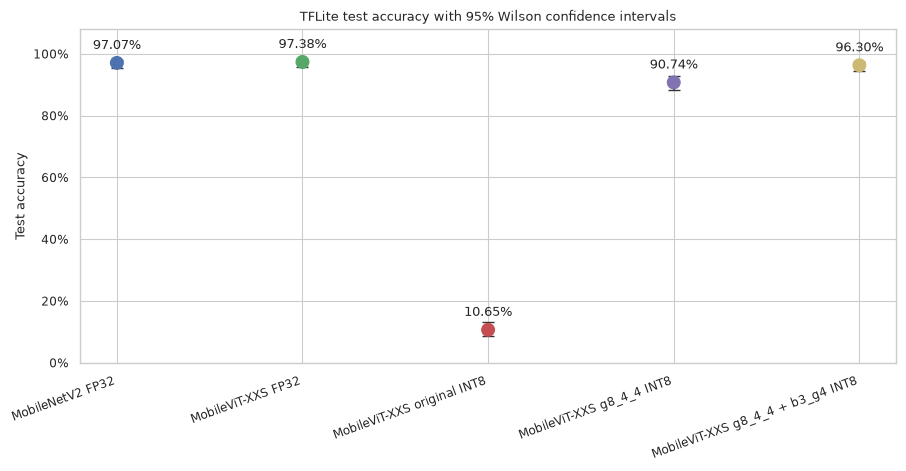

In [11]:
def wilson_interval(correct, total, alpha=0.05):
    proportion = correct / total
    z_value = norm.ppf(1 - alpha / 2)
    denominator = 1 + z_value**2 / total
    center = (proportion + z_value**2 / (2 * total)) / denominator
    margin = (z_value / denominator) * np.sqrt(
        proportion * (1 - proportion) / total + z_value**2 / (4 * total**2)
    )
    return center - margin, center + margin


def save_figure(figure, name):
    figure.savefig(FIGURES_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    figure.savefig(FIGURES_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()


accuracy_plot = model_accuracy.copy()
intervals = [wilson_interval(row.correct, row.samples, ALPHA) for row in accuracy_plot.itertuples()]
accuracy_plot["ci_lower"] = [interval[0] for interval in intervals]
accuracy_plot["ci_upper"] = [interval[1] for interval in intervals]

figure, axis = plt.subplots(figsize=(9.2, 4.8))
positions = np.arange(len(accuracy_plot))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
axis.errorbar(
    positions,
    accuracy_plot["accuracy"],
    yerr=[
        accuracy_plot["accuracy"] - accuracy_plot["ci_lower"],
        accuracy_plot["ci_upper"] - accuracy_plot["accuracy"],
    ],
    fmt="none",
    ecolor="#333333",
    capsize=4,
    linewidth=1.2,
)
axis.scatter(positions, accuracy_plot["accuracy"], s=85, color=colors, zorder=3)
for position, accuracy in zip(positions, accuracy_plot["accuracy"]):
    axis.text(position, min(accuracy + 0.045, 1.03), f"{accuracy:.2%}", ha="center", fontsize=9)
axis.set_xticks(positions)
axis.set_xticklabels(accuracy_plot["model"], rotation=20, ha="right")
axis.set_ylim(0, 1.08)
axis.set_ylabel("Test accuracy")
axis.set_title("TFLite test accuracy with 95% Wilson confidence intervals")
axis.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
figure.tight_layout()
save_figure(figure, "model_accuracy_with_wilson_ci")

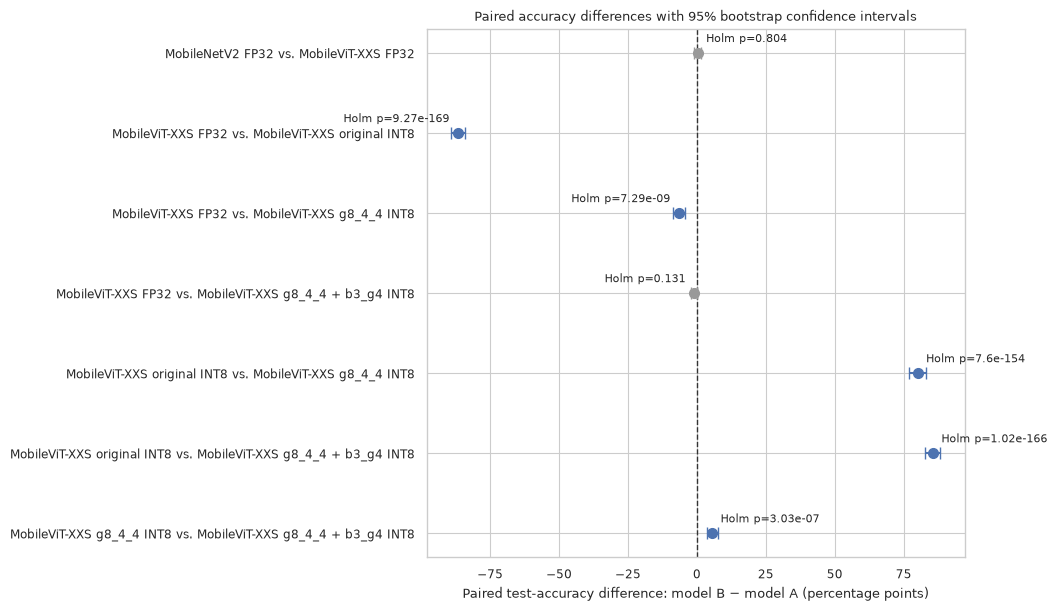

In [13]:
plt.close("all")

plot_results = mcnemar_results.iloc[::-1].reset_index(drop=True)
positions = np.arange(len(plot_results))
differences = 100 * plot_results["accuracy_difference_b_minus_a"].to_numpy()
lower = 100 * plot_results["difference_ci95_lower"].to_numpy()
upper = 100 * plot_results["difference_ci95_upper"].to_numpy()
significant = plot_results["significant_after_holm"].to_numpy(dtype=bool)
colors = np.where(significant, "#4C72B0", "#999999")

figure, axis = plt.subplots(figsize=(10.5, 6.2))
axis.axvline(0, color="#333333", linestyle="--", linewidth=1)

for position, difference, lower_bound, upper_bound, color in zip(
    positions,
    differences,
    lower,
    upper,
    colors,
):
    axis.errorbar(
        difference,
        position,
        xerr=[
            [max(0.0, difference - lower_bound)],
            [max(0.0, upper_bound - difference)],
        ],
        fmt="o",
        color=color,
        ecolor=color,
        markersize=7,
        capsize=4,
        linewidth=1.5,
        zorder=3,
    )

axis.set_yticks(positions)
axis.set_yticklabels(plot_results["comparison"])
axis.set_xlabel(
    "Paired test-accuracy difference: model B − model A (percentage points)"
)
axis.set_title(
    "Paired accuracy differences with 95% bootstrap confidence intervals"
)

for position, difference, p_value in zip(
    positions,
    differences,
    plot_results["holm_adjusted_p_value"],
):
    axis.annotate(
        f"Holm p={p_value:.3g}",
        (difference, position),
        xytext=(6 if difference >= 0 else -6, 8),
        textcoords="offset points",
        ha="left" if difference >= 0 else "right",
        fontsize=8,
    )

figure.tight_layout()
save_figure(figure, "mcnemar_paired_accuracy_differences")

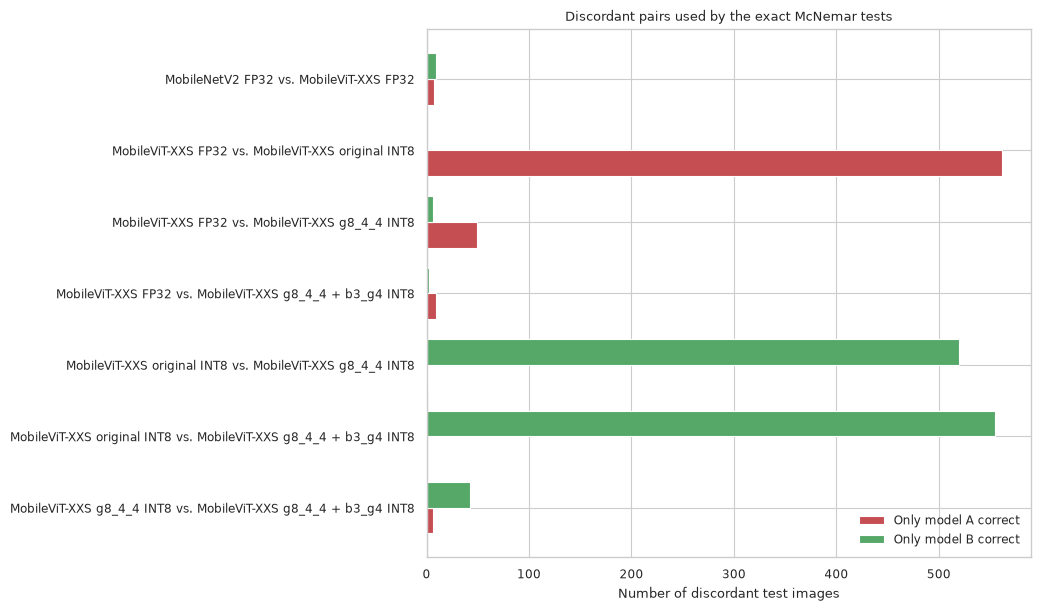

In [14]:
discordant_plot = mcnemar_results.iloc[::-1].reset_index(drop=True)
positions = np.arange(len(discordant_plot))
height = 0.36

figure, axis = plt.subplots(figsize=(10.5, 6.2))
axis.barh(
    positions - height / 2,
    discordant_plot["model_a_correct_model_b_wrong"],
    height=height,
    color="#C44E52",
    label="Only model A correct",
)
axis.barh(
    positions + height / 2,
    discordant_plot["model_a_wrong_model_b_correct"],
    height=height,
    color="#55A868",
    label="Only model B correct",
)
axis.set_yticks(positions)
axis.set_yticklabels(discordant_plot["comparison"] )
axis.set_xlabel("Number of discordant test images")
axis.set_title("Discordant pairs used by the exact McNemar tests")
axis.legend(frameon=False, loc="lower right")
figure.tight_layout()
save_figure(figure, "mcnemar_discordant_pairs")

## Resumo reproduzível

A interpretação deve considerar simultaneamente a direção e a magnitude da diferença, o intervalo de confiança, os pares discordantes e o valor de p corrigido. Significância estatística não implica relevância prática.

In [15]:
summary = {
    "test_samples": len(reference_targets),
    "classes": len(class_names),
    "mcnemar_variant": "two-sided exact binomial",
    "multiple_testing_correction": "Holm",
    "familywise_alpha": ALPHA,
    "bootstrap_samples": BOOTSTRAP_SAMPLES,
    "bootstrap_seed": RANDOM_SEED,
    "significant_comparisons_after_holm": mcnemar_results.loc[
        mcnemar_results["significant_after_holm"],
        "comparison",
    ].tolist(),
}

with (RESULTS_DIR / "experiment_summary.json").open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2, ensure_ascii=False)

print(json.dumps(summary, indent=2, ensure_ascii=False))
print(f"Tables saved to: {TABLES_DIR}")
print(f"Figures saved to: {FIGURES_DIR}")

{
  "test_samples": 648,
  "classes": 20,
  "mcnemar_variant": "two-sided exact binomial",
  "multiple_testing_correction": "Holm",
  "familywise_alpha": 0.05,
  "bootstrap_samples": 10000,
  "bootstrap_seed": 42,
  "significant_comparisons_after_holm": [
    "MobileViT-XXS FP32 vs. MobileViT-XXS original INT8",
    "MobileViT-XXS FP32 vs. MobileViT-XXS g8_4_4 INT8",
    "MobileViT-XXS original INT8 vs. MobileViT-XXS g8_4_4 INT8",
    "MobileViT-XXS original INT8 vs. MobileViT-XXS g8_4_4 + b3_g4 INT8",
    "MobileViT-XXS g8_4_4 INT8 vs. MobileViT-XXS g8_4_4 + b3_g4 INT8"
  ]
}
Tables saved to: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/mcnemar_teste/results/tables
Figures saved to: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/mcnemar_teste/results/figures


# Stats Models

In [16]:
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

In [17]:
def run_statsmodels_mcnemar(model_a, model_b):
    correct_a = predictions[model_a] == reference_targets
    correct_b = predictions[model_b] == reference_targets

    both_correct = int(np.sum(correct_a & correct_b))
    a_only = int(np.sum(correct_a & ~correct_b))
    b_only = int(np.sum(~correct_a & correct_b))
    both_wrong = int(np.sum(~correct_a & ~correct_b))

    contingency_table = np.array(
        [
            [both_correct, a_only],
            [b_only, both_wrong],
        ],
        dtype=np.int64,
    )

    result = mcnemar(
        contingency_table,
        exact=True,
        correction=False,
    )

    return {
        "comparison": f"{model_a} vs. {model_b}",
        "model_a": model_a,
        "model_b": model_b,
        "both_correct": both_correct,
        "model_a_correct_model_b_wrong": a_only,
        "model_a_wrong_model_b_correct": b_only,
        "both_wrong": both_wrong,
        "discordant_pairs": a_only + b_only,
        "mcnemar_statistic": float(result.statistic),
        "mcnemar_exact_p_value": float(result.pvalue),
        "accuracy_a": float(correct_a.mean()),
        "accuracy_b": float(correct_b.mean()),
        "accuracy_difference_b_minus_a": float(
            correct_b.mean() - correct_a.mean()
        ),
    }


statsmodels_results = pd.DataFrame(
    [
        run_statsmodels_mcnemar(model_a, model_b)
        for model_a, model_b in COMPARISONS
    ]
)

reject_null, adjusted_p_values, _, _ = multipletests(
    statsmodels_results["mcnemar_exact_p_value"],
    alpha=ALPHA,
    method="holm",
)

statsmodels_results["holm_adjusted_p_value"] = adjusted_p_values
statsmodels_results["significant_after_holm"] = reject_null
statsmodels_results["scipy_exact_p_value"] = mcnemar_results[
    "mcnemar_exact_p_value"
].to_numpy()
statsmodels_results["matches_scipy"] = np.isclose(
    statsmodels_results["mcnemar_exact_p_value"],
    statsmodels_results["scipy_exact_p_value"],
    rtol=1e-12,
    atol=1e-15,
)

statsmodels_results.to_csv(
    TABLES_DIR / "statsmodels_mcnemar_results.csv",
    index=False,
)

display_columns = [
    "comparison",
    "model_a_correct_model_b_wrong",
    "model_a_wrong_model_b_correct",
    "mcnemar_statistic",
    "accuracy_difference_b_minus_a",
    "mcnemar_exact_p_value",
    "holm_adjusted_p_value",
    "significant_after_holm",
    "matches_scipy",
]

display(
    statsmodels_results[display_columns].style.format(
        {
            "mcnemar_statistic": "{:.0f}",
            "accuracy_difference_b_minus_a": "{:+.2%}",
            "mcnemar_exact_p_value": "{:.6g}",
            "holm_adjusted_p_value": "{:.6g}",
        }
    )
)

,comparison,model_a_correct_model_b_wrong,model_a_wrong_model_b_correct,mcnemar_statistic,accuracy_difference_b_minus_a,mcnemar_exact_p_value,holm_adjusted_p_value,significant_after_holm,matches_scipy
0,MobileNetV2 FP32 vs. MobileViT-XXS FP32,7,9,7,+0.31%,0.803619,0.803619,False,True
1,MobileViT-XXS FP32 vs. MobileViT-XXS original INT8,562,0,0,-86.73%,1.32487e-169,9.27407e-169,True,True
2,MobileViT-XXS FP32 vs. MobileViT-XXS g8_4_4 INT8,49,6,6,-6.64%,1.82283e-09,7.29134e-09,True,True
3,MobileViT-XXS FP32 vs. MobileViT-XXS g8_4_4 + b3_g4 INT8,9,2,2,-1.08%,0.0654297,0.130859,False,True
4,MobileViT-XXS original INT8 vs. MobileViT-XXS g8_4_4 INT8,1,520,1,+80.09%,1.5208e-154,7.60401e-154,True,True
5,MobileViT-XXS original INT8 vs. MobileViT-XXS g8_4_4 + b3_g4 INT8,0,555,0,+85.65%,1.69583e-167,1.0175e-166,True,True
6,MobileViT-XXS g8_4_4 INT8 vs. MobileViT-XXS g8_4_4 + b3_g4 INT8,6,42,6,+5.56%,1.00875e-07,3.02624e-07,True,True


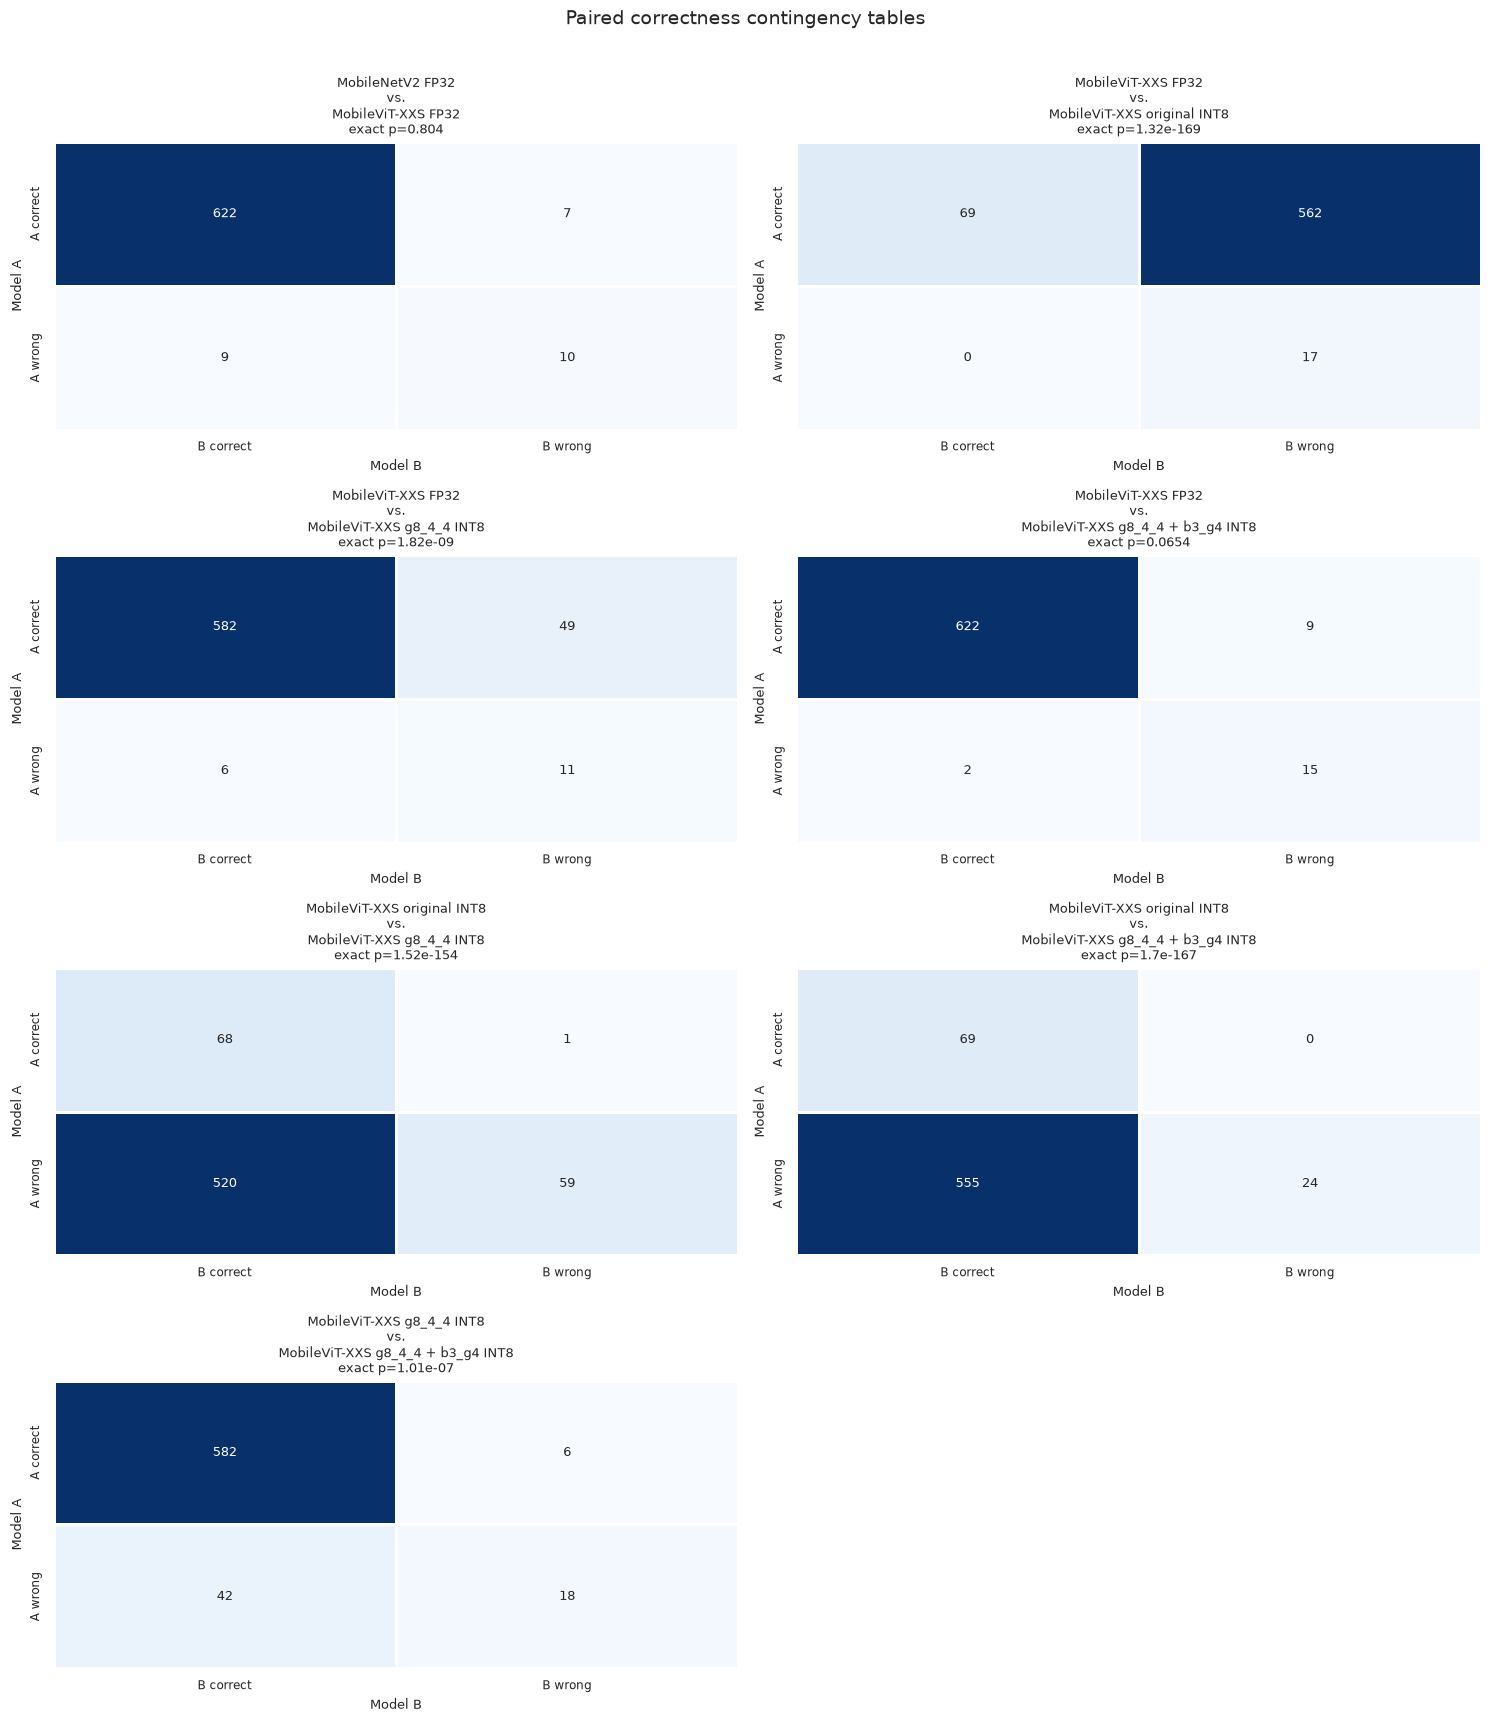

In [18]:
figure, axes = plt.subplots(4, 2, figsize=(15, 17))
axes = axes.ravel()

for axis, row in zip(axes, statsmodels_results.itertuples()):
    contingency_table = np.array(
        [
            [
                row.both_correct,
                row.model_a_correct_model_b_wrong,
            ],
            [
                row.model_a_wrong_model_b_correct,
                row.both_wrong,
            ],
        ]
    )

    sns.heatmap(
        contingency_table,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        linewidths=1,
        linecolor="white",
        xticklabels=["B correct", "B wrong"],
        yticklabels=["A correct", "A wrong"],
        ax=axis,
    )

    axis.set_title(
        f"{row.model_a}\nvs.\n{row.model_b}\n"
        f"exact p={row.mcnemar_exact_p_value:.3g}",
        fontsize=9,
    )
    axis.set_xlabel("Model B")
    axis.set_ylabel("Model A")

for axis in axes[len(statsmodels_results):]:
    axis.set_visible(False)

figure.suptitle(
    "Paired correctness contingency tables",
    fontsize=14,
    y=1.01,
)
figure.tight_layout()
save_figure(figure, "statsmodels_mcnemar_contingency_tables")

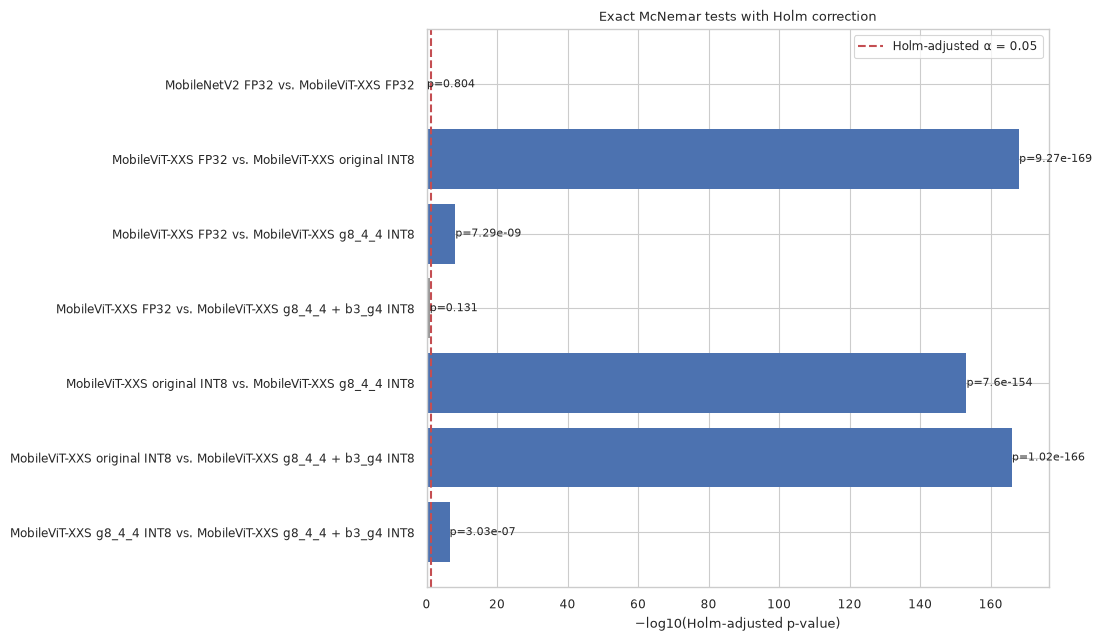

In [19]:
plot_results = statsmodels_results.iloc[::-1].reset_index(drop=True)
positions = np.arange(len(plot_results))
adjusted_p_values = plot_results["holm_adjusted_p_value"].to_numpy()
negative_log_p = -np.log10(
    np.clip(adjusted_p_values, np.finfo(float).tiny, 1.0)
)
significant = plot_results["significant_after_holm"].to_numpy(dtype=bool)
colors = np.where(significant, "#4C72B0", "#999999")
threshold = -np.log10(ALPHA)

figure, axis = plt.subplots(figsize=(11, 6.5))
axis.barh(
    positions,
    negative_log_p,
    color=colors,
    edgecolor="none",
)
axis.axvline(
    threshold,
    color="#C44E52",
    linestyle="--",
    linewidth=1.5,
    label=f"Holm-adjusted α = {ALPHA:.2f}",
)

axis.set_yticks(positions)
axis.set_yticklabels(plot_results["comparison"])
axis.set_xlabel("−log10(Holm-adjusted p-value)")
axis.set_title("Exact McNemar tests with Holm correction")

for position, value, p_value in zip(
    positions,
    negative_log_p,
    adjusted_p_values,
):
    axis.text(
        value + 0.03,
        position,
        f"p={p_value:.3g}",
        va="center",
        fontsize=8,
    )

axis.legend()
figure.tight_layout()
save_figure(figure, "statsmodels_mcnemar_holm_p_values")